# Bitcoin Utilities API Demo

This notebook demonstrates how to use the API functions provided in `bitcoin_utils.py`. It shows minimal working examples of:

- Loading and cleaning data.
- Updating the dataset with the latest data point from CoinGecko.
- Adding technical features.
- Generating LSTM-ready sequences.

This notebook focuses on **API usage only** (no model training or deep EDA).

See: `tensorflow.API.md` for detailed explanations.


References:
- [Causify API Tutorial Guide](https://github.com/causify-ai/helpers/blob/master/docs/coding/all.jupyter_notebook.how_to_guide.md)
- `bitcoin_utils.py`

---

In [2]:
# %load_ext autoreload
# %autoreload 2
%matplotlib inline

# Imports
import sys
sys.path.append("..")  # if needed to import bitcoin_utils.py

import numpy as np
import matplotlib.pyplot as plt

from bitcoin_utils import (
    load_and_clean_csv,
    update_dataset_with_latest,
    technical_features,
    generate_sequences,
    build_lstm_model,
    train_lstm_model,
    fine_tune_model,
    plot_training_loss,
    predict_next_price
)


2025-05-18 01:09:59.182590: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-18 01:09:59.184820: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-18 01:09:59.222799: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-18 01:09:59.223816: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-18 01:09:59.947058: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

## Step 1: Load and Clean Dataset

We load the Bitcoin dataset and clean it using the `load_and_clean_csv()` function.


In [3]:
# Path to the CSV
csv_path = 'btc-usd-max.csv'

# Load and clean
df = load_and_clean_csv(csv_path, remove_anomalies=True)

# Show the first few rows
df.head()


INFO:bitcoin_utils:Loading dataset from btc-usd-max.csv
INFO:bitcoin_utils:Removed 100 anomalous rows based on z-score > 3.0
INFO:bitcoin_utils:Dataset loaded: 4298 rows; columns: ['price', 'market_cap', 'total_volume']


,price,market_cap,total_volume
snapped_at,,,
2013-04-28 00:00:00+00:00,135.30,1.500518e+09,0.0
2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0
2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0
2013-05-01 00:00:00+00:00,117.00,1.298952e+09,0.0
2013-05-02 00:00:00+00:00,103.43,1.148668e+09,0.0


## Step 2: Update Dataset with Latest Price from CoinGecko

We fetch the latest Bitcoin data from CoinGecko and update the existing dataset using the `update_dataset_with_latest()` function.


In [4]:
# Update the dataset (this will fetch the latest data and append if needed)
update_dataset_with_latest(csv_path)

INFO:bitcoin_utils:Loading existing dataset from btc-usd-max.csv
INFO:bitcoin_utils:Fetching latest data point from CoinGecko
INFO:bitcoin_utils:Latest data point: {'snapped_at': Timestamp('2025-05-18 01:09:01+0000', tz='UTC'), 'price': 103327.67710217056, 'market_cap': 2052791378890.308, 'total_volume': 18760076216.655743}
INFO:bitcoin_utils:Appending new data point to the dataset.
INFO:bitcoin_utils:Dataset updated and saved to btc-usd-max.csv


## Step 3: Feature Engineering

We apply `technical_features()` to enrich the DataFrame with engineered columns.


In [5]:
# Add features
df = technical_features(df)
df = df.dropna()
df[["price", "SMA_7", "SMA_30", "volatility_7", "lag_1day"]].tail()


INFO:bitcoin_utils:Adding technical feature columns
INFO:bitcoin_utils:Feature engineering complete


,price,SMA_7,SMA_30,volatility_7,lag_1day
snapped_at,,,,,
2025-04-24 00:00:00+00:00,93605.452309,87742.593118,84225.373121,4109.157561,93576.165886
2025-04-25 00:00:00+00:00,93872.814229,89020.008211,84437.114131,4463.977502,93605.452309
2025-04-28 00:00:00+00:00,93809.337820,90359.377875,84665.396874,4260.459843,93872.814229
2025-04-30 00:00:00+00:00,94256.359463,91663.620306,84899.699803,3759.586079,93809.337820
2025-05-01 00:00:00+00:00,94235.753310,92972.561430,85228.909275,2449.333577,94256.359463


## Step 4: Generate Sequences for LSTM

We generate sequences using the `generate_sequences()` function for model-ready data.


In [6]:
features = ['price', 'returns', 'SMA_7', 'SMA_30', 'volatility_7', 'volatility_30', 'lag_1day']
X, y, scaler_X, scaler_y = generate_sequences(df, features, target='price', window_size=60)

print("X shape:", X.shape)
print("y shape:", y.shape)



INFO:bitcoin_utils:Generating sequences using features ['price', 'returns', 'SMA_7', 'SMA_30', 'volatility_7', 'volatility_30', 'lag_1day'] and target 'price'
INFO:bitcoin_utils:Generated 4209 sequences with shape (60, 7)


X shape: (4209, 60, 7)
y shape: (4209, 1)


## Step 5: Build and Train LSTM Model
Construct an LSTM model using the provided utility.


In [7]:
# Split into train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = build_lstm_model(input_shape=(X.shape[1], X.shape[2]))
model, history = train_lstm_model(model, X_train, y_train, X_test, y_test)


INFO:bitcoin_utils:Building LSTM model with input shape (60, 7)
INFO:bitcoin_utils:Training LSTM model for 50 epochs with batch size 32


Epoch 1/50
106/106 [==============================] - 7s 46ms/step - loss: 0.0022 - val_loss: 0.0030
Epoch 2/50
106/106 [==============================] - 4s 40ms/step - loss: 8.3950e-04 - val_loss: 0.0046
Epoch 3/50
106/106 [==============================] - 4s 38ms/step - loss: 8.6374e-04 - val_loss: 0.0012
Epoch 4/50
106/106 [==============================] - 4s 39ms/step - loss: 7.2963e-04 - val_loss: 0.0011
Epoch 5/50
106/106 [==============================] - 6s 53ms/step - loss: 7.6769e-04 - val_loss: 0.0042
Epoch 6/50
106/106 [==============================] - 4s 38ms/step - loss: 5.4922e-04 - val_loss: 8.6582e-04
Epoch 7/50
106/106 [==============================] - 4s 38ms/step - loss: 5.3814e-04 - val_loss: 8.8011e-04
Epoch 8/50
106/106 [==============================] - 4s 38ms/step - loss: 6.0765e-04 - val_loss: 9.7704e-04
Epoch 9/50
106/106 [==============================] - 4s 38ms/step - loss: 5.2063e-04 - val_loss: 9.2130e-04
Epoch 10/50
106/106 [======================

INFO:bitcoin_utils:Model training complete.


## Step 6: Visualize Training Loss
Plot training and validation loss to observe performance.

INFO:bitcoin_utils:Plotting training and validation loss.


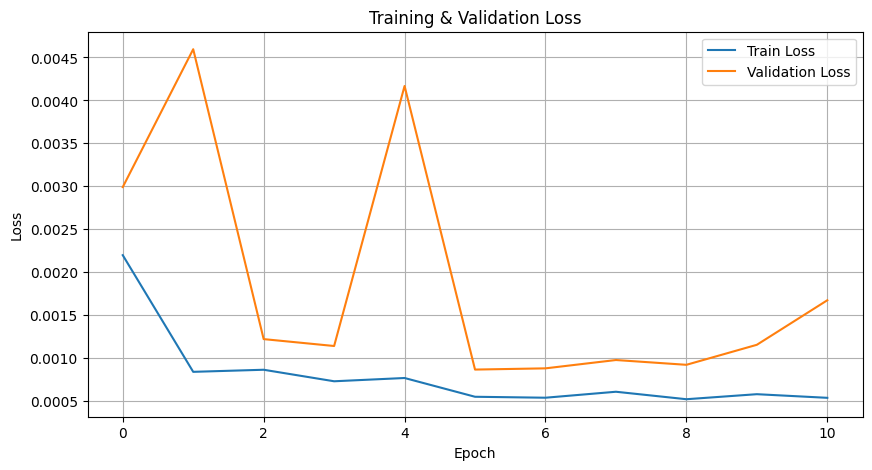

In [8]:
plot_training_loss(history)


## Step 7: Fine-Tune Model on Recent Data (Optional)
Use latest data to adapt the model before prediction.


In [9]:
# Fine-tune on latest data slice
X_recent, y_recent = X[-100:], y[-100:]
fine_tune_model("models/final_lstm_model.h5", X_recent, y_recent)


INFO:bitcoin_utils:Fine-tuning model at models/final_lstm_model.h5 on recent data...


Epoch 1/5
4/4 [==============================] - 1s 45ms/step - loss: 0.0117
Epoch 2/5
4/4 [==============================] - 0s 32ms/step - loss: 0.0104
Epoch 3/5
4/4 [==============================] - 0s 37ms/step - loss: 0.0080
Epoch 4/5
4/4 [==============================] - 0s 34ms/step - loss: 0.0075
Epoch 5/5
4/4 [==============================] - 0s 32ms/step - loss: 0.0072


/usr/local/lib/python3.8/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
INFO:bitcoin_utils: Model fine-tuned and saved.


## Step 8: Predict Next Price and Plot

We use the most recent input sequence and call `predict_next_price()` from the utility file.


INFO:bitcoin_utils:Predicting next Bitcoin price using latest sequence...


1/1 [==============================] - 0s 394ms/step


INFO:bitcoin_utils:Plotting recent prices with prediction...


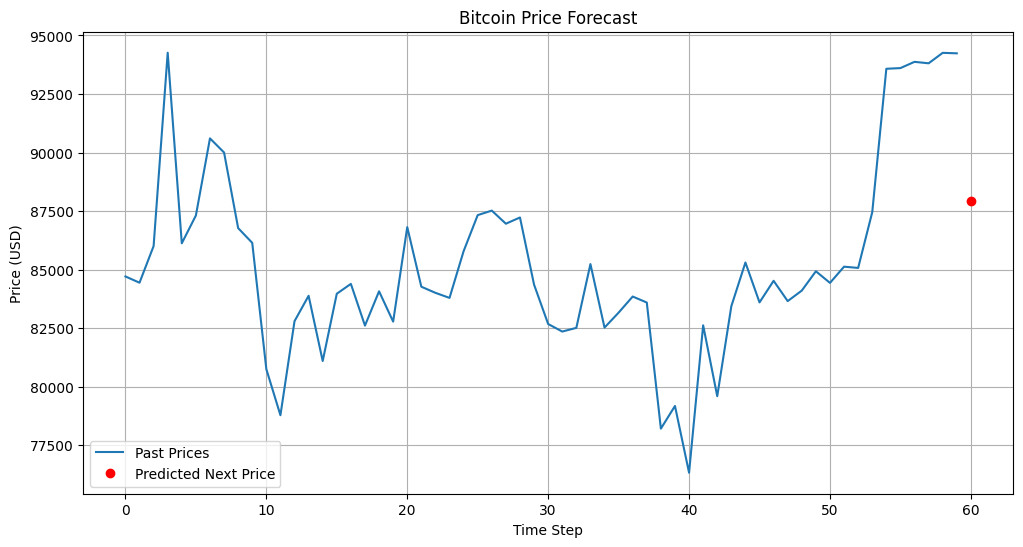

INFO:bitcoin_utils:Predicted price: $87,919.57


📈 Predicted Next Price: $87,919.57


In [10]:
from bitcoin_utils import predict_next_price

# Prepare last input
X_input = X[-1:].copy()
recent_prices = df['price'].iloc[-60:].values

# Predict and plot
predicted_price = predict_next_price(model, X_input, scaler_y, recent_prices, plot=True)
print(f"📈 Predicted Next Price: ${predicted_price:,.2f}")

